In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "ma_walk_forward_equity"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.width",
    180,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:.4f}",
)

plt.rcParams[
    "axes.unicode_minus"
] = False

import matplotlib.pyplot as plt
from matplotlib import font_manager


def configure_chinese_font() -> str | None:
    """
    从当前系统已安装字体中选择一个支持中文的字体。
    """
    preferred_fonts = [
        "Microsoft YaHei",
        "Microsoft YaHei UI",
        "SimHei",
        "SimSun",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]

    installed_fonts = {
        font.name
        for font in font_manager.fontManager.ttflist
    }

    for font_name in preferred_fonts:
        if font_name in installed_fonts:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [
                font_name
            ]
            plt.rcParams["axes.unicode_minus"] = False

            print(
                "Matplotlib 中文字体：",
                font_name,
            )

            return font_name

    print(
        "没有发现可用的中文字体，"
        "图中的中文可能无法正常显示"
    )

    return None


chinese_font = configure_chinese_font()


%load_ext autoreload
%autoreload 2

from walk_forward_equity import (
    build_dynamic_schedule,
    build_fixed_schedule,
    build_continuous_stock_detail,
    build_portfolio,
    summarize_portfolio,
    summarize_annual_returns,
    build_equity_comparison,
    plot_equity_curves,
    plot_drawdown_curves,
)

from parameter_sensitivity import (
    build_ma_parameter_grid,
)

from walk_forward import (
    generate_walk_forward_windows,
    run_ma_walk_forward,
    run_fixed_parameter_validation,
    plot_walk_forward_metric,
    plot_selected_parameters,
)

Matplotlib 中文字体： Microsoft YaHei
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
stock_list = [
    "000001",
    "000002",
    "300750",
    "600036",
    "600519",
]

fast_windows = [
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
]

slow_windows = [
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100,
    110,
    120,
]

parameter_grid = build_ma_parameter_grid(
    fast_windows=fast_windows,
    slow_windows=slow_windows,
    min_gap=10,
)



walk_forward_result = run_ma_walk_forward(
    stock_list=stock_list,
    parameter_grid=parameter_grid,
    train_months=36,
    test_months=12,
    step_months=12,
    window_type="rolling",
    start_date=None,
    end_date="2024-12-31",
    include_partial_test=False,
    commission_rate=0.0003,
    slippage_rate=0.0002,
    annual_risk_free_rate=0.0,
    trading_days=252,
    robustness_metric="avg_strategy_sharpe",
    stability_penalty=1.0,
    min_local_parameter_count=9,
    return_backtests=True,
)

## 构建连续净值对比

In [3]:
equity_result = build_equity_comparison(
    walk_forward_result=walk_forward_result,
    fixed_parameters=[
        (10, 40),
        (20, 60),
        (25, 110),
    ],
    dynamic_strategy_name="dynamic_rule_c",
    commission_rate=0.0003,
    slippage_rate=0.0002,
    annual_risk_free_rate=0.0,
    trading_days=252,
)

schedules = equity_result[
    "schedules"
]

stock_details = equity_result[
    "stock_details"
]

portfolios = equity_result[
    "portfolios"
]

summary = equity_result[
    "summary"
]

annual_summary = equity_result[
    "annual_summary"
]

for strategy_name, schedule in schedules.items():
    print(strategy_name)
    display(schedule)

dynamic_rule_c


,fold_id,fast_window,slow_window,ma_param
0,1,25,110,25/110
1,2,25,110,25/110
2,3,25,100,25/100


fixed_10_40


,fold_id,fast_window,slow_window,ma_param
0,1,10,40,10/40
1,2,10,40,10/40
2,3,10,40,10/40


fixed_20_60


,fold_id,fast_window,slow_window,ma_param
0,1,20,60,20/60
1,2,20,60,20/60
2,3,20,60,20/60


fixed_25_110


,fold_id,fast_window,slow_window,ma_param
0,1,25,110,25/110
1,2,25,110,25/110
2,3,25,110,25/110


## 正确性测试

In [5]:
windows = walk_forward_result[
    "windows"
].sort_values(
    "fold_id"
).reset_index(drop=True)

previous_end = (
    windows["test_end"]
    .shift(1)
)

expected_start = (
    previous_end
    + pd.Timedelta(days=1)
)

assert (
    windows.loc[
        previous_end.notna(),
        "test_start",
    ].reset_index(drop=True)
    ==
    expected_start[
        previous_end.notna()
    ].reset_index(drop=True)
).all()

print("测试窗口首尾相接")

for strategy_name, detail in stock_details.items():
    assert not detail.duplicated(
        [
            "symbol",
            "date",
        ]
    ).any()

    expected_return = (
        detail[
            "gross_strategy_return"
        ]
        - detail[
            "transaction_cost"
        ]
    )

    assert np.allclose(
        detail[
            "strategy_return"
        ],
        expected_return,
    )

    print(
        strategy_name,
        "逐日收益检查通过",
    )
    
one_way_cost = (
    0.0003
    + 0.0002
)

for strategy_name, detail in stock_details.items():
    fold_starts = detail.loc[
        detail["is_fold_start"]
    ]

    expected_cost = (
        fold_starts[
            "position_change"
        ].abs()
        * one_way_cost
    )

    assert np.allclose(
        fold_starts[
            "transaction_cost"
        ],
        expected_cost,
    )

    print(
        strategy_name,
        "折边界交易成本检查通过",
    )
    
for strategy_name in [
    "fixed_10_40",
    "fixed_20_60",
    "fixed_25_110",
]:
    assert not stock_details[
        strategy_name
    ][
        "is_parameter_switch"
    ].any()

print("固定参数切换检查通过")

for strategy_name, portfolio in portfolios.items():
    assert not portfolio[
        "date"
    ].duplicated().any()

    assert (
        portfolio[
            "strategy_nav"
        ] > 0
    ).all()

    assert (
        portfolio[
            "benchmark_nav"
        ] > 0
    ).all()

    expected_returns = (
        portfolio[
            "strategy_nav"
        ].pct_change()
    )

    expected_returns.iloc[0] = (
        portfolio[
            "strategy_nav"
        ].iloc[0]
        - 1.0
    )

    assert np.allclose(
        portfolio[
            "strategy_return"
        ],
        expected_returns,
    )

    print(
        strategy_name,
        "连续净值检查通过",
    )
    
strategy_names = list(
    portfolios.keys()
)

reference_benchmark = portfolios[
    strategy_names[0]
][
    [
        "date",
        "benchmark_return",
    ]
].reset_index(drop=True)

for strategy_name in strategy_names[1:]:
    candidate_benchmark = portfolios[
        strategy_name
    ][
        [
            "date",
            "benchmark_return",
        ]
    ].reset_index(drop=True)

    pd.testing.assert_frame_equal(
        reference_benchmark,
        candidate_benchmark,
        check_dtype=False,
    )

print("全部策略使用相同基准")



测试窗口首尾相接
dynamic_rule_c 逐日收益检查通过
fixed_10_40 逐日收益检查通过
fixed_20_60 逐日收益检查通过
fixed_25_110 逐日收益检查通过
dynamic_rule_c 折边界交易成本检查通过
fixed_10_40 折边界交易成本检查通过
fixed_20_60 折边界交易成本检查通过
fixed_25_110 折边界交易成本检查通过
固定参数切换检查通过
dynamic_rule_c 连续净值检查通过
fixed_10_40 连续净值检查通过
fixed_20_60 连续净值检查通过
fixed_25_110 连续净值检查通过
全部策略使用相同基准


## 查看绩效

In [11]:
summary_columns = [
    "strategy_name",
    "strategy_cumulative_return",
    "strategy_annual_return",
    "strategy_annual_volatility",
    "strategy_sharpe",
    "strategy_max_drawdown",
    "strategy_calmar",
    "excess_annual_return",
    "sharpe_diff",
    "drawdown_improvement",
    "information_ratio",
    "average_exposure",
    "average_daily_turnover",
    "total_trade_count",
    "total_transaction_cost",
    "total_boundary_cost_adjustment",
]

display(
    summary[
        summary_columns
    ].sort_values(
        "strategy_sharpe",
        ascending=False,
    )
)

,strategy_name,strategy_cumulative_return,strategy_annual_return,strategy_annual_volatility,strategy_sharpe,strategy_max_drawdown,strategy_calmar,excess_annual_return,sharpe_diff,drawdown_improvement,information_ratio,average_exposure,average_daily_turnover,total_trade_count,total_transaction_cost,total_boundary_cost_adjustment
0,fixed_10_40,-0.1247,-0.0452,0.1258,-0.3054,-0.2014,-0.2246,0.1055,0.2691,0.2497,0.5407,0.4072,0.0279,104,0.0101,0.0004
1,fixed_20_60,-0.2019,-0.0754,0.1136,-0.6334,-0.2779,-0.2713,0.0753,-0.0588,0.1732,0.3420,0.3939,0.0191,70,0.0069,0.0004
2,dynamic_rule_c,-0.2847,-0.1099,0.1049,-1.0574,-0.3456,-0.3180,0.0408,-0.4828,0.1054,0.1247,0.3610,0.0125,46,0.0045,0.0004
3,fixed_25_110,-0.2936,-0.1138,0.1043,-1.1058,-0.3539,-0.3215,0.0369,-0.5313,0.0971,0.1017,0.3571,0.0125,46,0.0045,0.0004


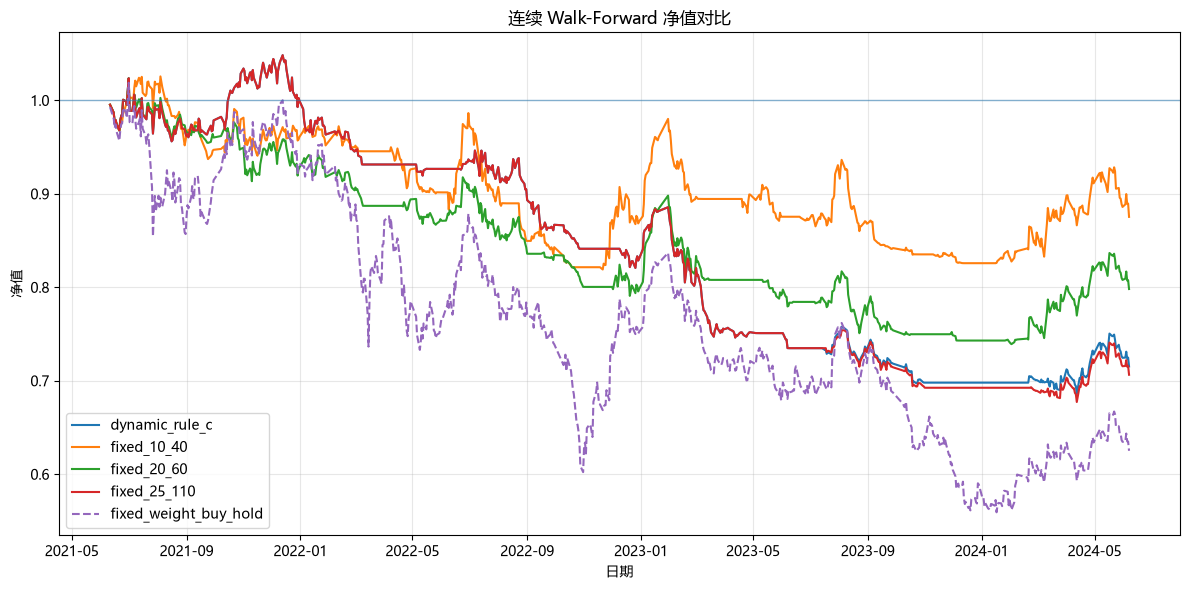

In [12]:
fig_equity, ax_equity = (
    plot_equity_curves(
        portfolios
    )
)

plt.show()

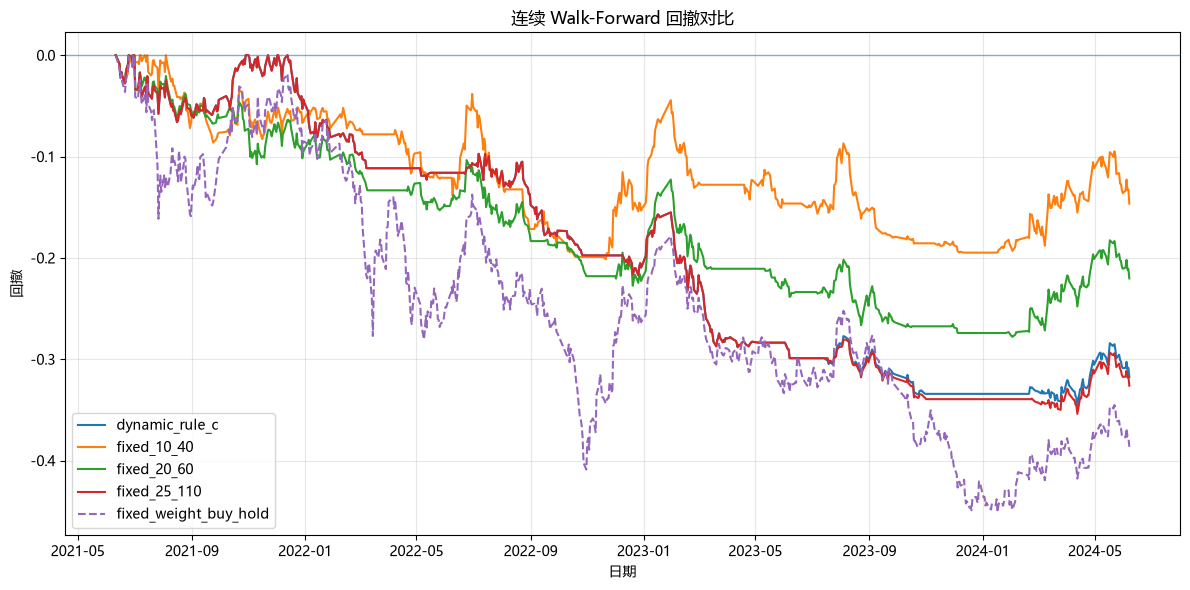

In [13]:
fig_drawdown, ax_drawdown = (
    plot_drawdown_curves(
        portfolios
    )
)

plt.show()

## 年度收益分析

In [14]:
annual_display_columns = [
    "strategy_name",
    "year",
    "trade_days",
    "strategy_return",
    "benchmark_return",
    "excess_return",
    "strategy_sharpe",
    "strategy_max_drawdown",
]

display(
    annual_summary[
        annual_display_columns
    ].sort_values(
        [
            "year",
            "strategy_name",
        ]
    )
)

,strategy_name,year,trade_days,strategy_return,benchmark_return,excess_return,strategy_sharpe,strategy_max_drawdown
0,dynamic_rule_c,2021,138,-0.0007,-0.0681,0.0674,0.0623,-0.0660
4,fixed_10_40,2021,138,-0.0391,-0.0681,0.0289,-0.4980,-0.0862
8,fixed_20_60,2021,138,-0.0717,-0.0681,-0.0036,-0.9363,-0.1076
12,fixed_25_110,2021,138,-0.0007,-0.0681,0.0674,0.0623,-0.0660
1,dynamic_rule_c,2022,242,-0.1688,-0.1927,0.0239,-2.2387,-0.1716
5,fixed_10_40,2022,242,-0.0941,-0.1927,0.0986,-0.6964,-0.1696
9,fixed_20_60,2022,242,-0.1403,-0.1927,0.0524,-1.5803,-0.1601
13,fixed_25_110,2022,242,-0.1688,-0.1927,0.0239,-2.2387,-0.1716
2,dynamic_rule_c,2023,242,-0.1598,-0.2174,0.0575,-1.8295,-0.2126
6,fixed_10_40,2023,242,-0.0514,-0.2174,0.1660,-0.5048,-0.1575


In [15]:
annual_return_matrix = (
    annual_summary.pivot(
        index="year",
        columns="strategy_name",
        values="strategy_return",
    )
)

display(
    annual_return_matrix
)

strategy_name,dynamic_rule_c,fixed_10_40,fixed_20_60,fixed_25_110
year,,,,
2021,-0.0007,-0.0391,-0.0717,-0.0007
2022,-0.1688,-0.0941,-0.1403,-0.1688
2023,-0.1598,-0.0514,-0.0690,-0.1664
2024,0.0249,0.0600,0.0742,0.0201


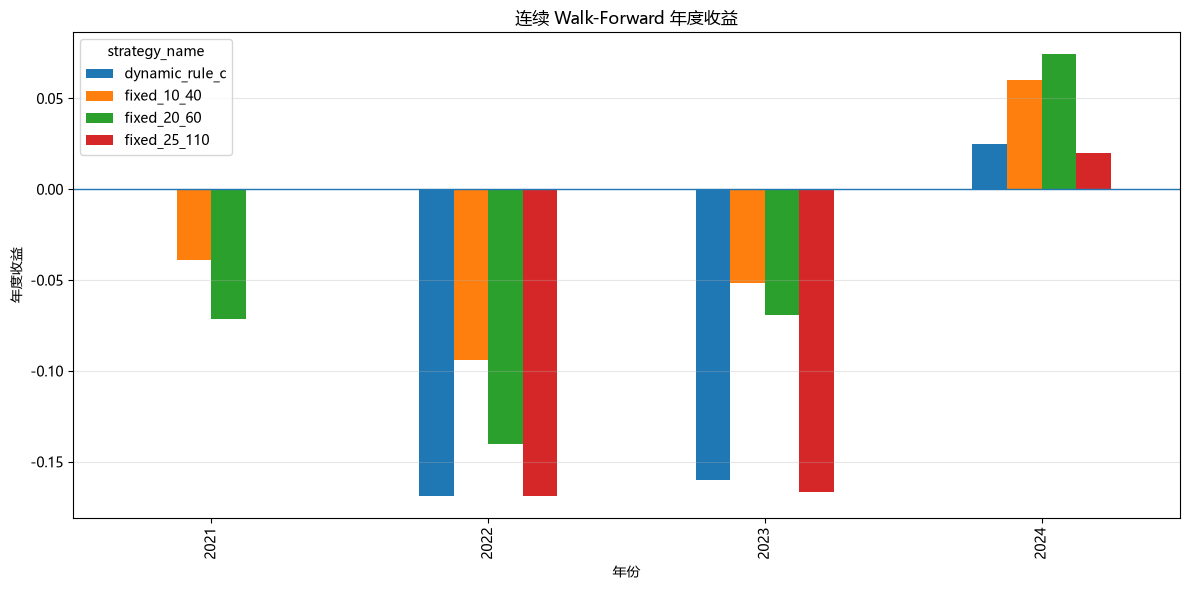

In [16]:
ax = annual_return_matrix.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.set_title(
    "连续 Walk-Forward 年度收益"
)

ax.set_xlabel("年份")
ax.set_ylabel("年度收益")
ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

## 按测试折分析

In [17]:
fold_rows = []

for strategy_name, portfolio in portfolios.items():
    for fold_id, fold_data in portfolio.groupby(
        "fold_id"
    ):
        strategy_return = (
            (
                1.0
                + fold_data[
                    "strategy_return"
                ]
            ).prod()
            - 1.0
        )

        benchmark_return = (
            (
                1.0
                + fold_data[
                    "benchmark_return"
                ]
            ).prod()
            - 1.0
        )

        fold_rows.append(
            {
                "strategy_name": (
                    strategy_name
                ),
                "fold_id": int(
                    fold_id
                ),
                "start_date": (
                    fold_data[
                        "date"
                    ].iloc[0]
                ),
                "end_date": (
                    fold_data[
                        "date"
                    ].iloc[-1]
                ),
                "strategy_return": (
                    strategy_return
                ),
                "benchmark_return": (
                    benchmark_return
                ),
                "excess_return": (
                    strategy_return
                    - benchmark_return
                ),
                "max_drawdown": (
                    fold_data[
                        "strategy_drawdown"
                    ].min()
                ),
            }
        )

fold_summary = pd.DataFrame(
    fold_rows
)

display(
    fold_summary.sort_values(
        [
            "fold_id",
            "strategy_name",
        ]
    )
)

,strategy_name,fold_id,start_date,end_date,strategy_return,benchmark_return,excess_return,max_drawdown
0,dynamic_rule_c,1,2021-06-11,2022-06-10,-0.0734,-0.2080,0.1346,-0.1229
3,fixed_10_40,1,2021-06-11,2022-06-10,-0.0991,-0.2080,0.1089,-0.1390
6,fixed_20_60,1,2021-06-11,2022-06-10,-0.1177,-0.2080,0.0903,-0.1531
9,fixed_25_110,1,2021-06-11,2022-06-10,-0.0734,-0.2080,0.1346,-0.1229
1,dynamic_rule_c,2,2022-06-13,2023-06-09,-0.2070,-0.1320,-0.0750,-0.2990
4,fixed_10_40,2,2022-06-13,2023-06-09,-0.0283,-0.1320,0.1037,-0.2014
7,fixed_20_60,2,2022-06-13,2023-06-09,-0.1119,-0.1320,0.0200,-0.2385
10,fixed_25_110,2,2022-06-13,2023-06-09,-0.2070,-0.1320,-0.0750,-0.2990
2,dynamic_rule_c,3,2023-06-12,2024-06-07,-0.0266,-0.0908,0.0643,-0.3456
5,fixed_10_40,3,2023-06-12,2024-06-07,-0.0002,-0.0908,0.0907,-0.1948


In [18]:
fold_stability = (
    fold_summary.groupby(
        "strategy_name",
        as_index=False,
    )
    .agg(
        fold_count=(
            "fold_id",
            "nunique",
        ),
        avg_fold_return=(
            "strategy_return",
            "mean",
        ),
        median_fold_return=(
            "strategy_return",
            "median",
        ),
        worst_fold_return=(
            "strategy_return",
            "min",
        ),
        avg_excess_return=(
            "excess_return",
            "mean",
        ),
        positive_excess_fold_rate=(
            "excess_return",
            lambda values: (
                values > 0
            ).mean(),
        ),
    )
)

display(
    fold_stability.sort_values(
        "avg_excess_return",
        ascending=False,
    )
)

,strategy_name,fold_count,avg_fold_return,median_fold_return,worst_fold_return,avg_excess_return,positive_excess_fold_rate
1,fixed_10_40,3,-0.0425,-0.0283,-0.0991,0.1011,1.0000
2,fixed_20_60,3,-0.0703,-0.1119,-0.1177,0.0732,1.0000
0,dynamic_rule_c,3,-0.1023,-0.0734,-0.2070,0.0413,0.6667
3,fixed_25_110,3,-0.1064,-0.0734,-0.2070,0.0372,0.6667


### 分析参数切换成本

In [20]:
dynamic_detail = stock_details[
    "dynamic_rule_c"
]

dynamic_boundary = dynamic_detail.loc[
    dynamic_detail[
        "is_fold_start"
    ],
    [
        "symbol",
        "fold_id",
        "date",
        "selected_ma_param",
        "position",
        "position_change",
        "transaction_cost",
        "source_transaction_cost",
        "boundary_cost_adjustment",
        "is_parameter_switch",
    ],
]
boundary_summary = (
    dynamic_boundary.groupby(
        "fold_id",
        as_index=False,
    )
    .agg(
        selected_ma_param=(
            "selected_ma_param",
            "first",
        ),
        parameter_switch=(
            "is_parameter_switch",
            "max",
        ),
        stock_trade_count=(
            "position_change",
            lambda values: (
                values.abs() > 0
            ).sum(),
        ),
        boundary_transaction_cost=(
            "transaction_cost",
            "sum",
        ),
        boundary_cost_adjustment=(
            "boundary_cost_adjustment",
            "sum",
        ),
    )
)

display(boundary_summary)

,fold_id,selected_ma_param,parameter_switch,stock_trade_count,boundary_transaction_cost,boundary_cost_adjustment
0,1,25/110,False,4,0.0020,0.0020
1,2,25/110,False,0,0.0000,0.0000
2,3,25/100,True,0,0.0000,0.0000


In [21]:
REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

summary.to_csv(
    REPORT_DIR
    / "continuous_strategy_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

annual_summary.to_csv(
    REPORT_DIR
    / "continuous_annual_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

fold_summary.to_csv(
    REPORT_DIR
    / "continuous_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

fold_stability.to_csv(
    REPORT_DIR
    / "continuous_fold_stability.csv",
    index=False,
    encoding="utf-8-sig",
)

boundary_summary.to_csv(
    REPORT_DIR
    / "dynamic_boundary_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

for strategy_name, portfolio in portfolios.items():
    portfolio.to_csv(
        REPORT_DIR
        / f"{strategy_name}_portfolio.csv",
        index=False,
        encoding="utf-8-sig",
    )
    
for strategy_name, detail in stock_details.items():
    detail.to_csv(
        REPORT_DIR
        / f"{strategy_name}_stock_detail.csv",
        index=False,
        encoding="utf-8-sig",
    )
    
fig_equity.savefig(
    REPORT_DIR
    / "continuous_equity_curves.png",
    dpi=160,
    bbox_inches="tight",
)

fig_drawdown.savefig(
    REPORT_DIR
    / "continuous_drawdown_curves.png",
    dpi=160,
    bbox_inches="tight",
)



## 连续 Walk-Forward 净值分析结论

### 1. 整体收益

- 累计收益最高的策略：10/40
- 年化收益最高的策略：10/40
- 固定 10/40 是否仍然优于动态规则 C：是
- 是否有策略长期优于买入持有：是

### 2. 风险调整后收益

- 夏普最高的策略：10/40
- Calmar 最高的策略：10/40
- 信息比率最高的策略：10/40
- 动态调参是否提高了风险调整后收益：些许提高，但仍然表现很差

### 3. 回撤表现

- 最大回撤最小的策略：10/40
- 固定 10/40 的回撤改善：0.2497
- 动态规则 C 是否通过降低收益换取了更小回撤：动态规则收益更高且回撤更低

### 4. 跨时期稳定性

- 正超额收益折数比例最高的策略：10/40
- 最差一折表现最好的策略：10/40
- 是否存在单独一年贡献大部分收益：是，只有2024年年度收益为正，其他的都为负
- 固定 10/40 是否在多数年份保持优势：是

### 5. 交易成本与复杂度

- 动态策略参数切换次数：1
- 参数切换额外成本：0
- 动态策略交易次数是否明显增加：否
- 动态策略增加的复杂度是否值得：否

### 6. 当前决策

- 是否继续使用固定 10/40：是
- 是否保留动态规则 C：否
- 是否需要研究参数组合：需要
- 是否准备进入市场状态归因分析：暂不

## Walk-Forward 选参有效性结论

当前 Walk-Forward 时间切分框架没有表现出明显错误，但训练期使用的规则 C 未能有效预测下一测试期的参数表现。

规则 C 在训练窗口中主要选择了 `25/110` 和 `25/100`，但这些参数在后续测试期的夏普、超额收益和胜率均表现较差。相比之下，固定参数 `10/40` 在连续测试期中的累计收益、年化收益、夏普、Calmar、信息比率、最大回撤和跨时期稳定性方面表现更好。

这说明当前训练期的平均夏普、超额收益过滤和局部稳健性分数，与下一测试期的实际表现缺乏稳定关系。动态调参增加了研究复杂度，但没有产生相应的样本外价值，因此当前决定停止使用规则 C 动态调参。

固定 `10/40` 是当前开发数据中的主要候选参数，但由于它最初来自与后续比较区间存在重叠的历史回测，其优势仍可能包含事后选择偏差。因此目前不能将其定义为已经得到独立样本外证明的最优参数。

后续将固定 `10/40`，不再根据当前历史区间调整参数，并通过未参与参数选择的新时间区间、未参与选择的股票或参数区域组合进一步检验其泛化能力。
